# Ridge Regression

---
## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = './processed'
OUT_DIR       = '../project/outputs/ridge_regression'
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/models',  exist_ok=True)

print('Config OK. Output directory:', OUT_DIR)

Config OK. Output directory: ../project/outputs/ridge_regression


---
# Load Pre-Processed Artefacts

In [2]:
# Scaled splits
X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0)
X_val   = pd.read_csv(f'{PROCESSED_DIR}/X_val_scaled.csv',   index_col=0)
X_test  = pd.read_csv(f'{PROCESSED_DIR}/X_test_scaled.csv',  index_col=0)

# Regression targets
y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
y_reg_val   = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv',   index_col=0).squeeze()
y_reg_test  = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv',  index_col=0).squeeze()

feature_names = pd.read_csv(f'{PROCESSED_DIR}/feature_list.csv')['feature'].tolist()

print('Loaded splits:')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:5s}  {arr.shape[0]:6d} rows  {arr.shape[1]} features')
print(f'\nRegression target  — mean={y_reg_train.mean():.2f}, std={y_reg_train.std():.2f}')

Loaded splits:
  Train   64000 rows  49 features
  Val      8000 rows  49 features
  Test     8000 rows  49 features

Regression target  — mean=89.15, std=11.57


In [3]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = X_train.select_dtypes(include='object').columns.tolist()

if cat_cols:
    print(f"Encoding categorical columns: {cat_cols}")
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[cat_cols] = enc.fit_transform(X_train[cat_cols])
    X_val[cat_cols]   = enc.transform(X_val[cat_cols])
    X_test[cat_cols]  = enc.transform(X_test[cat_cols])
else:
    print("No categorical columns found — all good.")

No categorical columns found — all good.


In [4]:
#Dropping features that have entirely NaN values in the training set
cols_to_drop = ['stress_level', 'parental_support_level', 'motivation_level', 'stress_anxiety_composite']

X_train = X_train.drop(columns=cols_to_drop)
X_val   = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print(f"Remaining features: {X_train.shape[1]}")
print(f"Any NaNs left: {X_train.isna().sum().sum()}")

feature_names = X_train.columns.tolist() 

Remaining features: 45
Any NaNs left: 0


---
## Ridge Regression

In [5]:
class RidgeRegression:

    def __init__(self, lambda_=1.0):
        self.lambda_ = lambda_
        self.beta_   = None 

    @staticmethod
    def _add_bias(X):
        """Prepend a column of ones to X."""
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def fit(self, X, y):
        X_b  = self._add_bias(np.asarray(X, dtype=float))
        y_   = np.asarray(y, dtype=float)

        n_params = X_b.shape[1]

        # Build penalty matrix
        pen      = self.lambda_ * np.eye(n_params)
        pen[0, 0] = 0.0

        A = X_b.T @ X_b + pen
        b = X_b.T @ y_
        self.beta_ = np.linalg.solve(A, b)
        return self

    def predict(self, X):
        X_b = self._add_bias(np.asarray(X, dtype=float))
        return X_b @ self.beta_

    @property
    def intercept_(self):
        return self.beta_[0]

    @property
    def coef_(self):
        return self.beta_[1:]

X_train_np = np.asarray(X_train, dtype=float)
X_val_np   = np.asarray(X_val,   dtype=float)
y_train_np = np.asarray(y_reg_train, dtype=float)
y_val_np   = np.asarray(y_reg_val,   dtype=float)

test_lambda = 10.0
rr = RidgeRegression(lambda_=test_lambda).fit(X_train, y_reg_train)

rr_rmse = np.sqrt(mean_squared_error(y_reg_val, rr.predict(X_val)))

print(f'Ridge Regression val RMSE: {rr_rmse:.6f}')

Ridge Regression val RMSE: 10.515036


---
## Regression Task — Predict `exam_score`

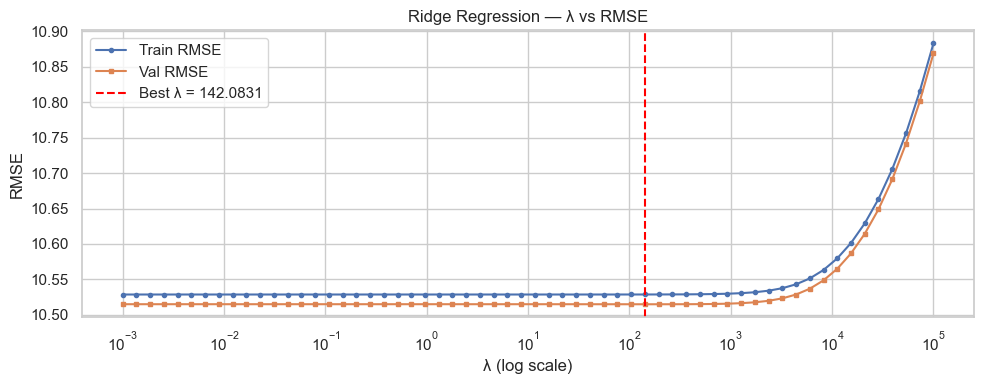

Best λ by val RMSE: 142.0831  (val RMSE=10.5150)


In [6]:
lambdas = np.logspace(-3, 5, 60) 

train_rmses, val_rmses = [], []

for lam in lambdas:
    m = RidgeRegression(lambda_=lam).fit(X_train, y_reg_train)
    train_rmses.append(np.sqrt(mean_squared_error(y_reg_train, m.predict(X_train))))
    val_rmses.append(np.sqrt(mean_squared_error(y_reg_val,   m.predict(X_val))))

best_lam_idx = np.argmin(val_rmses)
best_lam_reg = lambdas[best_lam_idx]

plt.figure(figsize=(10, 4))
plt.semilogx(lambdas, train_rmses, 'o-', markersize=3, label='Train RMSE')
plt.semilogx(lambdas, val_rmses,   's-', markersize=3, label='Val RMSE')
plt.axvline(best_lam_reg, color='red', linestyle='--',
            label=f'Best λ = {best_lam_reg:.4f}')
plt.xlabel('λ (log scale)')
plt.ylabel('RMSE')
plt.title('Ridge Regression — λ vs RMSE')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_lambda_vs_rmse.png', dpi=150)
plt.show()
print(f'Best λ by val RMSE: {best_lam_reg:.4f}  (val RMSE={val_rmses[best_lam_idx]:.4f})')

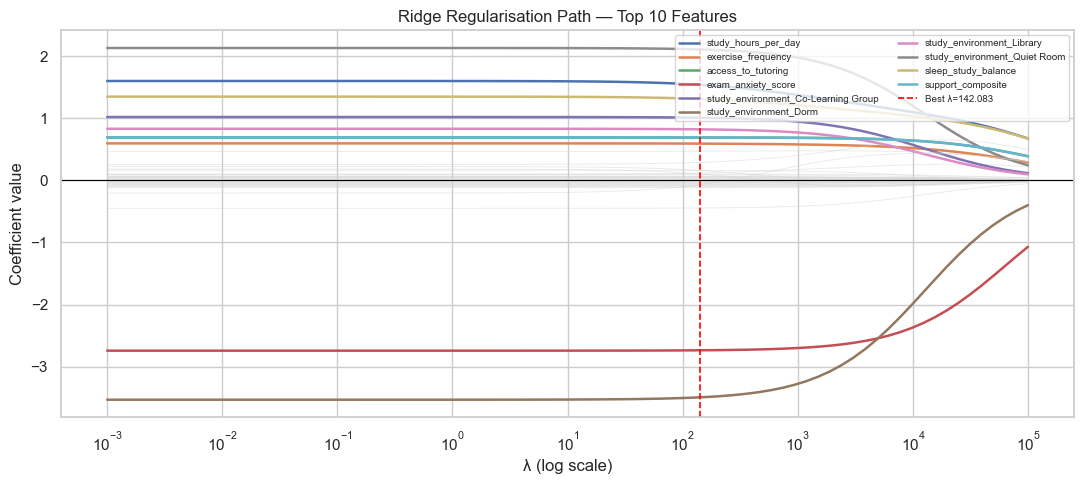

In [7]:
path_lambdas = np.logspace(-3, 5, 80)
coef_paths   = []

for lam in path_lambdas:
    m = RidgeRegression(lambda_=lam).fit(X_train, y_reg_train)
    coef_paths.append(m.coef_)

coef_paths = np.array(coef_paths)   # (n_lambdas, n_features)

# Highlight only the top-10 features by absolute coefficient at best lambda
best_model_path = RidgeRegression(lambda_=best_lam_reg).fit(X_train, y_reg_train)
top10_idx = np.argsort(np.abs(best_model_path.coef_))[::-1][:10]

plt.figure(figsize=(11, 5))
for i in range(len(feature_names)):
    if i in top10_idx:
        plt.semilogx(path_lambdas, coef_paths[:, i],
                     lw=1.8, label=feature_names[i])
    else:
        plt.semilogx(path_lambdas, coef_paths[:, i],
                     color='lightgray', lw=0.6, alpha=0.5)
plt.axvline(best_lam_reg, color='red', linestyle='--', lw=1.2, label=f'Best λ={best_lam_reg:.3f}')
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('λ (log scale)')
plt.ylabel('Coefficient value')
plt.title('Ridge Regularisation Path — Top 10 Features')
plt.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_regularisation_path.png', dpi=150)
plt.show()

In [8]:
# Combine train + val for final fit
X_trainval  = pd.concat([X_train, X_val])
y_reg_trainval = pd.concat([y_reg_train, y_reg_val])

best_ridge_reg = RidgeRegression(lambda_=best_lam_reg)
best_ridge_reg.fit(X_trainval, y_reg_trainval)

y_reg_pred = best_ridge_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
r2   = r2_score(y_reg_test, y_reg_pred)

print('─' * 35)
print(f'  Best λ   : {best_lam_reg:.4f}')
print(f'  RMSE     : {rmse:.3f}')
print(f'  MAE      : {mae:.3f}')
print(f'  R²       : {r2:.4f}')
print('─' * 35)

───────────────────────────────────
  Best λ   : 142.0831
  RMSE     : 10.673
  MAE      : 8.773
  R²       : 0.1772
───────────────────────────────────


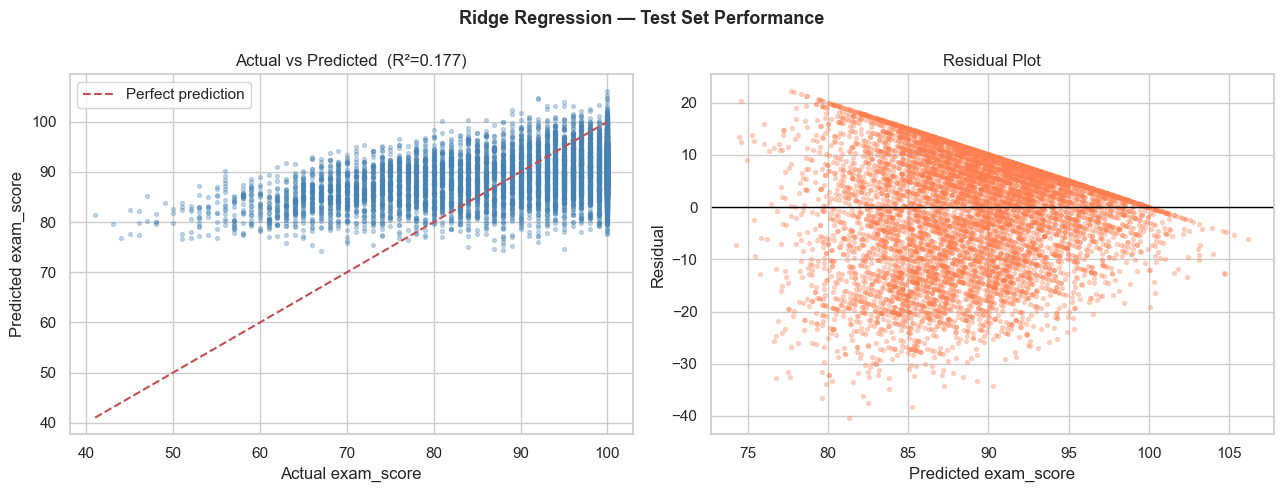

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=8, color='steelblue')
lims = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual exam_score')
axes[0].set_ylabel('Predicted exam_score')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_reg_test.values - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted exam_score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.suptitle('Ridge Regression — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_actual_vs_predicted.png', dpi=150)
plt.show()

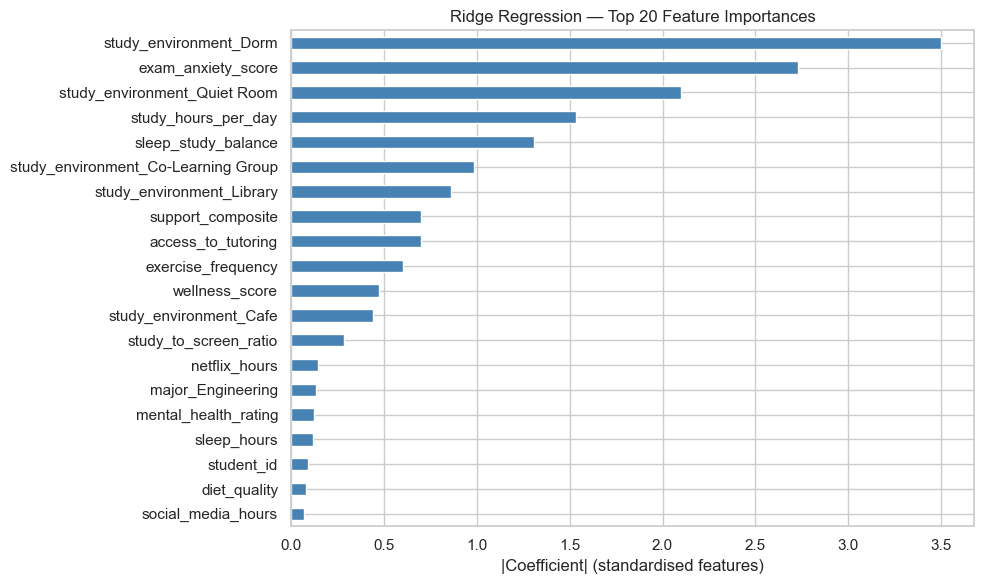

In [10]:
importances_reg = pd.Series(np.abs(best_ridge_reg.coef_), index=feature_names)
top20_reg = importances_reg.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20_reg.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('|Coefficient| (standardised features)')
plt.title('Ridge Regression — Top 20 Feature Importances')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_feature_importances.png', dpi=150)
plt.show()

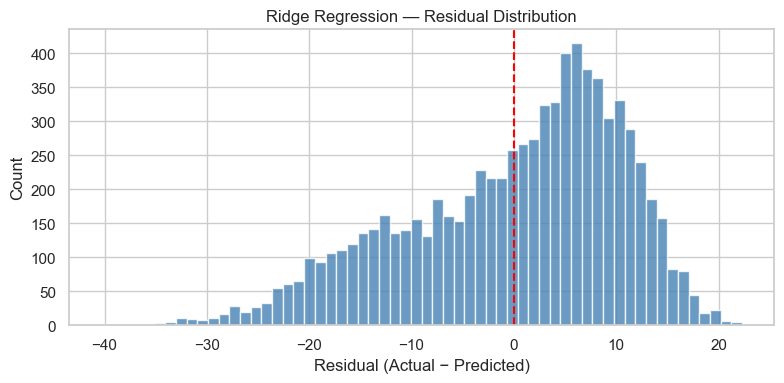

Residual mean : -0.0471
Residual std  : 10.6731


In [11]:
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', lw=1.5)
plt.xlabel('Residual (Actual − Predicted)')
plt.ylabel('Count')
plt.title('Ridge Regression — Residual Distribution')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_residual_distribution.png', dpi=150)
plt.show()
print(f'Residual mean : {residuals.mean():.4f}')
print(f'Residual std  : {residuals.std():.4f}')

In [12]:
import joblib
joblib.dump(best_ridge_reg, f'{OUT_DIR}/models/ridge_reg.joblib')
print(f'Ridge regression model saved  (λ={best_lam_reg:.4f})')

Ridge regression model saved  (λ=142.0831)


---
## Results Summary

In [13]:
summary = pd.DataFrame([
    {
        'Task':        'Regression (exam_score)',
        'Best λ':      f'{best_lam_reg:.4f}',
        'Test RMSE':   f'{rmse:.3f}',
        'Test MAE':    f'{mae:.3f}',
        'Test R²':     f'{r2:.4f}',
    }
])
display(summary)

print('\nAll figures saved to:', f'{OUT_DIR}/figures/')
print('All models saved to: ', f'{OUT_DIR}/models/')

,Task,Best λ,Test RMSE,Test MAE,Test R²
0,Regression (exam_score),142.0831,10.673,8.773,0.1772



All figures saved to: ../project/outputs/ridge_regression/figures/
All models saved to:  ../project/outputs/ridge_regression/models/
